In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('spam.csv')

UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 606-607: invalid continuation byte

In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [4]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5130,ham,Any way where are you and what doing.,NaN,NaN,NaN
3796,ham,For The First Time In The History 'Need' 'Comf...,NaN,NaN,NaN
2809,ham,Mm so you asked me not to call radio,NaN,NaN,NaN
3269,ham,K actually can you guys meet me at the sunoco ...,NaN,NaN,NaN
593,ham,You still at grand prix?,NaN,NaN,NaN


In [5]:
df.shape

(5572, 5)

Data cleaning

In [6]:
df.info

<bound method DataFrame.info of         v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [8]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=true)

NameError: name 'true' is not defined

In [9]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [10]:
df.sample()

,v1,v2
4105,ham,K then 2marrow are you coming to class.


In [11]:
df.sample(5)

,v1,v2
240,ham,Tomarrow final hearing on my laptop case so i ...
5563,ham,Ard 6 like dat lor.
3252,ham,K:)k..its good:)when are you going?
4129,ham,And by when you're done I mean now
2118,spam,U can WIN å£100 of Music Gift Vouchers every w...


In [12]:
df.rename(columns={'v1':'Target','v2':'Text'}inplace=True)
df.sample()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2022102749.py, line 1)

In [13]:
df.rename(columns={'v1':'Target','v2':'Text'},inplace=True)
df.sample()

,Target,Text
3830,ham,Let's pool our money together and buy a bunch ...


In [14]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [19]:
df['target']=encoder.fit_transform(df['Target'])

In [17]:
print(df.columns)

Index(['Target', 'Text'], dtype='object')


In [20]:
encoder.fit_transform(df['Target'])

array([0, 0, 1, ..., 0, 0, 0], shape=(5572,))

In [21]:
df['Target']=encoder.fit_transform(df['Target'])

In [22]:
df.head()

,Target,Text,target
0,0,"Go until jurong point, crazy.. Available only ...",0
1,0,Ok lar... Joking wif u oni...,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,0,U dun say so early hor... U c already then say...,0
4,0,"Nah I don't think he goes to usf, he lives aro...",0


In [24]:
#missing values
df.isnull().sum()

Target    0
Text      0
target    0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(403)

In [27]:
df.drop_duplicates(keep='first')

,Target,Text,target
0,0,"Go until jurong point, crazy.. Available only ...",0
1,0,Ok lar... Joking wif u oni...,0
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,0,U dun say so early hor... U c already then say...,0
4,0,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,1
5568,0,Will Ì_ b going to esplanade fr home?,0
5569,0,"Pity, * was in mood for that. So...any other s...",0
5570,0,The guy did some bitching but I acted like i'd...,0


In [28]:
df.duplicated().sum()

np.int64(403)

In [29]:
df= df.drop_duplicates(keep='first')

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.shape()

TypeError: 'tuple' object is not callable

In [32]:
df.shape

(5169, 3)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Target  5169 non-null   int64 
 1   Text    5169 non-null   object
 2   target  5169 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 161.5+ KB


In [37]:
df.drop(columns=['column:target'],inplace=True)

KeyError: "['column:target'] not found in axis"

In [38]:
df.columns

Index(['Target', 'Text'], dtype='object')

In [39]:
df = df.drop(columns=['target'])

KeyError: "['target'] not found in axis"

In [40]:
df.shape

(5169, 2)

EDA

In [41]:
df.head()

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [43]:
df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

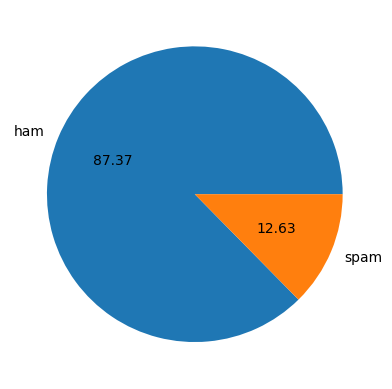

In [45]:
import matplotlib.pyplot as plt
plt.pie(df['Target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [48]:
import nltk

In [59]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [55]:
df['num_characters']= df['Text'].apply(len)

C:\Users\User\AppData\Local\Temp\ipykernel_9812\2404724417.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_characters']= df['Text'].apply(len)


In [56]:
df.head()

,Target,Text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [58]:
#num of words
df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\User/nltk_data'
    - 'C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python310\\nltk_data'
    - 'C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python310\\share\\nltk_data'
    - 'C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python310\\lib\\nltk_data'
    - 'C:\\Users\\User\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [60]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [62]:
df['num_words']= df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))

C:\Users\User\AppData\Local\Temp\ipykernel_9812\2849944625.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_words']= df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))


In [63]:
df.head()

,Target,Text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [66]:
df['num_words']= df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))

C:\Users\User\AppData\Local\Temp\ipykernel_9812\2849944625.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_words']= df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))


In [67]:
df.head()

,Target,Text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [69]:
 df['Text'].apply(lambda x: nltk.sent_tokenize(x))

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568              [Will Ì_ b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: Text, Length: 5169, dtype: object

In [70]:
df['num_sentence']= df['Text'].apply(lambda x: len(nltk.sent_tokenize(x)))

C:\Users\User\AppData\Local\Temp\ipykernel_9812\1083684070.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_sentence']= df['Text'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [71]:
df.head()

,Target,Text,num_characters,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [72]:
df[['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [73]:
df[df['Target']==0][['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [74]:
df[df['Target']==1][['num_characters','num_words','num_sentence']].describe()

,num_characters,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


 Data Preprocessing

In [98]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

     text = y[:]
     y.clear()
     for i in text:
         if i not in stopwords.words('english') and i not in string.panctuation:
             y.append(i)
    return y

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 10)

In [101]:
transform_text('Hii how are uhh  mine?')

['hii', 'how', 'are', 'uhh', 'mine']

In [102]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [92]:
import nltk
nltk.download('stopwords')  

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [93]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [96]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [120]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]  
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]  
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [121]:
 transform_text('i am learning the machine and data learning')

'learn machin data learn'

In [114]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [295]:
df['transform_text']=df['Text'].apply(transform_text)

C:\Users\User\AppData\Local\Temp\ipykernel_9812\1562877658.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['transform_text']=df['Text'].apply(transform_text)


In [297]:
df.head()

,Target,Text,num_characters,num_words,num_sentence,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [298]:
from sklearn.utils import resample

spam = df[df['Target']==1]
ham = df[df['Target']==0]

ham_downsample = resample(ham,
                         replace=False,
                         n_samples=len(spam),
                         random_state=42)

df = pd.concat([ham_downsample, spam])


In [299]:
from wordcloud import WordCloud
wc =WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [300]:
spam_wc=wc.generate(df[df['Target'] == 1]['transform_text'].str.cat(sep=" "))

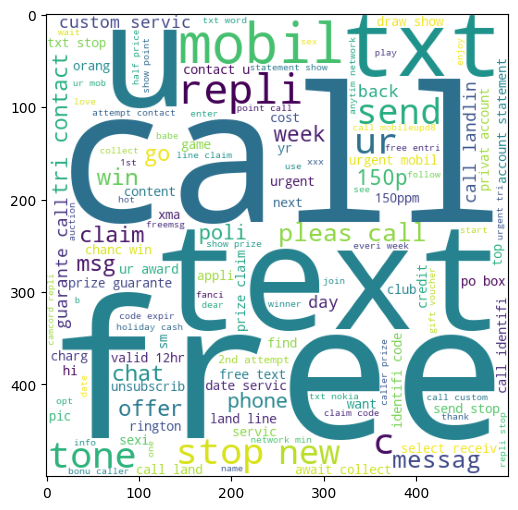

In [301]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [302]:
ham_wc=wc.generate(df[df['Target'] == 0]['transform_text'].str.cat(sep=" "))

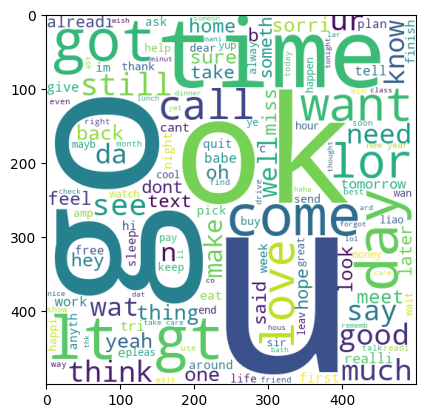

In [303]:
plt.imshow(ham_wc)

In [304]:
df.head()

,Target,Text,num_characters,num_words,num_sentence,transform_text
1883,0,"Come to me, slave. Your doing it again ... Goi...",128,28,3,come slave go shell unconsci avoid make unhappi
1709,0,U meet other fren dun wan meet me ah... Muz b ...,59,16,1,u meet fren dun wan meet ah muz b guy rite
4919,0,"G says you never answer your texts, confirm/deny",48,9,1,g say never answer text
1297,0,"K so am I, how much for an 8th? Fifty?",38,13,2,k much 8th fifti
3948,0,HMM yeah if your not too grooved out! And im l...,83,19,2,hmm yeah groov im look forward pound special


In [305]:
spam_corpus=[]
for msg in df[df['Target']==1]['transform_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [306]:
len(spam_corpus)

9939

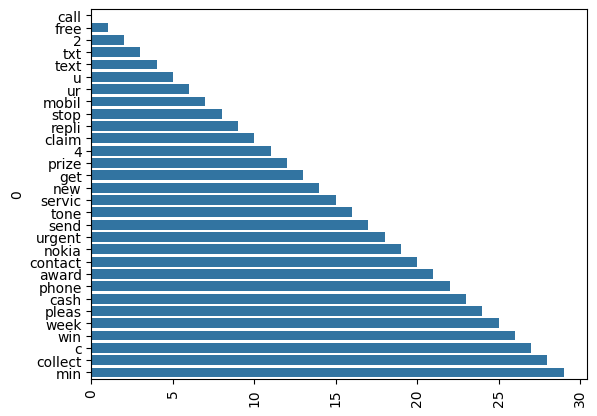

In [307]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0]),pd.DataFrame(Counter(spam_corpus).most_common(30))[1]
plt.xticks(rotation='vertical')
plt.show()

In [308]:
import seaborn as sns

In [309]:
ham_corpus=[]
for msg in df[df['Target']==0]['transform_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [310]:
len(ham_corpus)

5096

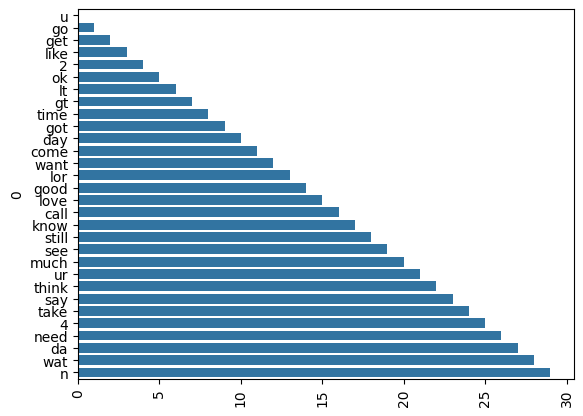

In [311]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(30))[0]),pd.DataFrame(Counter(ham_corpus).most_common(30))[1]
plt.xticks(rotation='vertical')
plt.show()

Model Building

In [312]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

In [313]:
X = tfidf.fit_transform(df['transform_text'])

In [314]:
X.shape

(1306, 5000)

In [315]:
y =df['Target'].values

In [316]:
y

array([0, 0, 0, ..., 1, 1, 1], shape=(1306,))

In [317]:
from sklearn.model_selection import train_test_split

In [318]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)


In [319]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [320]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [321]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

TypeError: Sparse data was passed for X, but dense data is required. Use '.toarray()' to convert to a dense numpy array.

In [322]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9389312977099237
[[127   3]
 [ 13 119]]
0.9754098360655737


In [323]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.916030534351145
[[130   0]
 [ 22 110]]
1.0


In [324]:
#tfidf--> mnb

In [325]:
df[['Text','transform_text']].head()

,Text,transform_text
1883,"Come to me, slave. Your doing it again ... Goi...",come slave go shell unconsci avoid make unhappi
1709,U meet other fren dun wan meet me ah... Muz b ...,u meet fren dun wan meet ah muz b guy rite
4919,"G says you never answer your texts, confirm/deny",g say never answer text
1297,"K so am I, how much for an 8th? Fifty?",k much 8th fifti
3948,HMM yeah if your not too grooved out! And im l...,hmm yeah groov im look forward pound special


In [329]:
df['Target'].value_counts()

Target
0    653
1    653
Name: count, dtype: int64

In [330]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

In [328]:
print("singl" in tfidf.vocabulary_)
print("click" in tfidf.vocabulary_)


True
True
